In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm # Displays a progress bar

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, Subset, DataLoader, random_split

In [2]:
# Load the dataset and train, val, test splits
print("Loading datasets...")
FASHION_transform = transforms.Compose([
    transforms.ToTensor(), # Transform from [0,255] uint8 to [0,1] float
    transforms.Normalize([0.2859], [0.3530]) # Normalize to zero mean and unit variance
])
FASHION_trainval = datasets.FashionMNIST('.', download=True, train=True, transform=FASHION_transform)
FASHION_train = Subset(FASHION_trainval, range(50000))
FASHION_val = Subset(FASHION_trainval, range(50000,60000))
FASHION_test = datasets.FashionMNIST('.', download=True, train=False, transform=FASHION_transform)
print("Done!")

Loading datasets...


100%|██████████| 26421880/26421880 [00:13<00:00, 1945894.75it/s]


Extracting ./FashionMNIST/raw/train-images-idx3-ubyte.gz to ./FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 279571.64it/s]


Extracting ./FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:03<00:00, 1360291.12it/s]


Extracting ./FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 12481084.97it/s]

Extracting ./FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./FashionMNIST/raw

Done!


In [21]:
# Create dataloaders
# TODO: Experiment with different batch sizes
trainloader = DataLoader(FASHION_train, batch_size=32, shuffle=True)
valloader = DataLoader(FASHION_val, batch_size=32, shuffle=True)
testloader = DataLoader(FASHION_test, batch_size=32, shuffle=True)

In [22]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Design your own network, define layers here.
        # Here We provide a sample of two-layer fully-connected network from HW4 Part3.
        # Your solution, however, should contain convolutional layers.
        # Refer to PyTorch documentations of torch.nn to pick your layers. (https://pytorch.org/docs/stable/nn.html)
        # Some common Choices are: Linear, Conv2d, ReLU, MaxPool2d, AvgPool2d, Dropout
        # If you have many layers, consider using nn.Sequential() to simplify your code
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)  # Conv layer 1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # Conv layer 2
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Fully connected layer
        self.fc2 = nn.Linear(128, 10)  # Output layer (10 classes)
        self.pool = nn.MaxPool2d(2, 2)  # Max pooling
        self.dropout = nn.Dropout(0.25)  # Dropout for regularization

    def forward(self,x):
        # TODO: Design your own network, implement forward pass here
        x = self.pool(F.relu(self.conv1(x)))  # First convolutional layer with ReLU and pooling
        x = self.pool(F.relu(self.conv2(x)))  # Second convolutional layer with ReLU and pooling
        x = x.view(-1, 64 * 7 * 7)  # Flatten
        x = F.relu(self.fc1(x))  # First fully connected layer with ReLU
        x = self.dropout(x)  # Apply dropout
        x = self.fc2(x)  # Output layer
        # The loss layer will be applied outside Network class
        return x

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu" # Configure device
model = Network().to(device)
criterion = nn.CrossEntropyLoss() # Specify the loss layer
# TODO: Modify the line below, experiment with different optimizers and parameters (such as learning rate)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # Specify optimizer and assign trainable parameters to it, weight_decay is L2 regularization strength
num_epoch = 15 # TODO: Choose an appropriate number of training epochs

In [30]:
def train(model, loader,valloader, num_epoch = 10): # Train the model
    print("Start training...")
    model.train() # Set the model to training mode
    training_loss = []
    val_losses = []
    for i in range(num_epoch):
        # Training Phase
        model.train()  # Ensure the model is in training mode
        running_loss = []
        for batch, label in tqdm(loader):
            batch = batch.to(device)
            label = label.to(device)
            optimizer.zero_grad() # Clear gradients from the previous iteration
            pred = model(batch) # This will call Network.forward() that you implement
            loss = criterion(pred, label) # Calculate the loss
            running_loss.append(loss.item())
            loss.backward() # Backprop gradients to all tensors in the network
            optimizer.step() # Update trainable weights
        print("Epoch {} loss:{}".format(i+1,np.mean(running_loss))) # Print the average loss for this epoch
        avg_loss = np.mean(running_loss)
        training_loss.append(avg_loss) 

         # Validation Phase
        model.eval()  # Set the model to evaluation mode
        running_val_loss = []

        with torch.no_grad():  # Disable gradient computation
            for batch, label in valloader:
                batch = batch.to(device)
                label = label.to(device)
                pred = model(batch)
                loss = criterion(pred, label)  # Calculate the validation loss
                running_val_loss.append(loss.item())
        
        # Record average validation loss for this epoch
        avg_val_loss = np.mean(running_val_loss)
        val_losses.append(avg_val_loss)
        print(f"Epoch {i+1} validation loss: {avg_val_loss:.4f}")
    print("Done!")
    return training_loss, val_losses

def evaluate(model, loader): # Evaluate accuracy on validation / test set
    model.eval() # Set the model to evaluation mode
    correct = 0
    with torch.no_grad(): # Do not calculate grident to speed up computation
        for batch, label in tqdm(loader):
            batch = batch.to(device)
            label = label.to(device)
            pred = model(batch)
            correct += (torch.argmax(pred,dim=1)==label).sum().item()
    acc = correct/len(loader.dataset)
    print("Evaluation accuracy: {}".format(acc))
    return acc

In [31]:
train_losses, val_losses = train(model, trainloader,valloader, num_epoch)

Start training...


100%|██████████| 1563/1563 [00:11<00:00, 130.56it/s]


Epoch 1 loss:0.4458281985476317
Epoch 1 validation loss: 0.3001


100%|██████████| 1563/1563 [00:11<00:00, 131.11it/s]


Epoch 2 loss:0.29310537806294396
Epoch 2 validation loss: 0.2860


...

Epoch 13 loss:0.11398840457634787
Epoch 13 validation loss: 0.2535


100%|██████████| 1563/1563 [00:12<00:00, 130.00it/s]


Epoch 14 loss:0.10821472387537431
Epoch 14 validation loss: 0.2513


100%|██████████| 1563/1563 [00:12<00:00, 130.04it/s]


Epoch 15 loss:0.10475119490814601
Epoch 15 validation loss: 0.2668
Done!


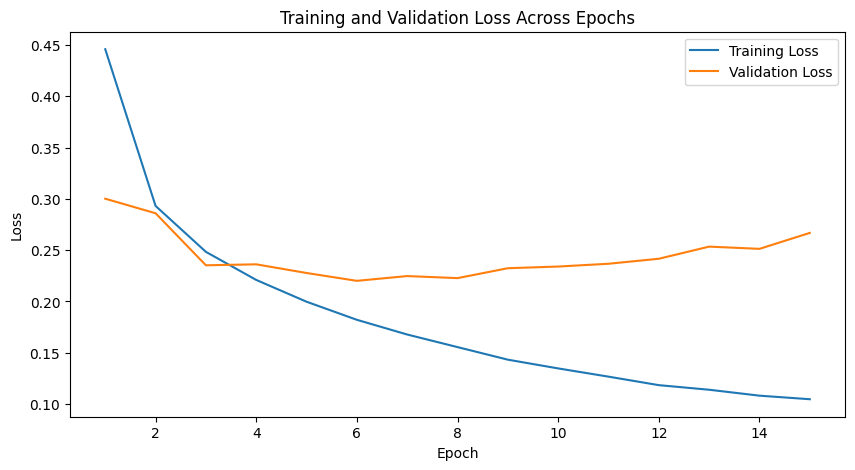

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epoch + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epoch + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend()
plt.show()

In [33]:
print("Evaluate on validation set...")
evaluate(model, valloader)

Evaluate on validation set...


100%|██████████| 313/313 [00:01<00:00, 157.44it/s]

Evaluation accuracy: 0.9206


0.9206

In [34]:
print("Evaluate on test set")
evaluate(model, testloader)


Evaluate on test set


100%|██████████| 313/313 [00:01<00:00, 157.45it/s]

Evaluation accuracy: 0.9157


0.9157